In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [12]:
import pandas as pd

# Show all columns when printing dataframe
pd.set_option("display.max_columns", None)

# Load your dataset
df = pd.read_csv("india_housing_prices.csv")

# Show first 5 rows
df.head()


,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,Furnished,22,1,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,Unfurnished,21,20,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,Semi-furnished,19,27,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,Furnished,21,26,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,Semi-furnished,3,2,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [13]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing per column:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())


Shape: (250000, 23)

Columns: ['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']

Data types:
 ID                                  int64
State                              object
City                               object
Locality                           object
Property_Type                      object
BHK                                 int64
Size_in_SqFt                        int64
Price_in_Lakhs                    float64
Price_per_SqFt                    float64
Year_Built                          int64
Furnished_Status                   object
Floor_No                            int64
Total_Floors                        int64
Age_of_Property                     int64
Nearby_Schools

In [14]:
# Numeric columns: fill with median
num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

# Categorical columns: fill with mode
cat_cols = df.select_dtypes(include=["object"]).columns
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

print("Total missing after fill:", df.isnull().sum().sum())


Total missing after fill: 0


In [5]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"Removed {before - after} duplicates → new shape: {df.shape}")


Removed 0 duplicates → new shape: (250000, 23)


In [15]:
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])
    df["year"]  = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"]   = df["date"].dt.day
    df = df.drop(columns=["date"])
df.head(3)


,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,Furnished,22,1,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,Unfurnished,21,20,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,Semi-furnished,19,27,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move


In [16]:
def binarize_yes_no(series):
    s = series.astype(str).str.strip().str.lower()
    if set(s.unique()) <= {"yes","no"}:
        return s.map({"no":0, "yes":1})
    return series

for c in df.columns:
    if df[c].dtype == "object":
        df[c] = binarize_yes_no(df[c])

df.head(3)


,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,Furnished,22,1,35,10,3,High,0,0,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,Unfurnished,21,20,17,8,1,Low,0,1,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,Semi-furnished,19,27,28,9,8,Low,1,0,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move


In [8]:
cols_to_drop = [c for c in ["street","country","id"] if c in df.columns]
df = df.drop(columns=cols_to_drop)
df.shape


(250000, 23)

In [11]:
print(df.columns.tolist())


['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']


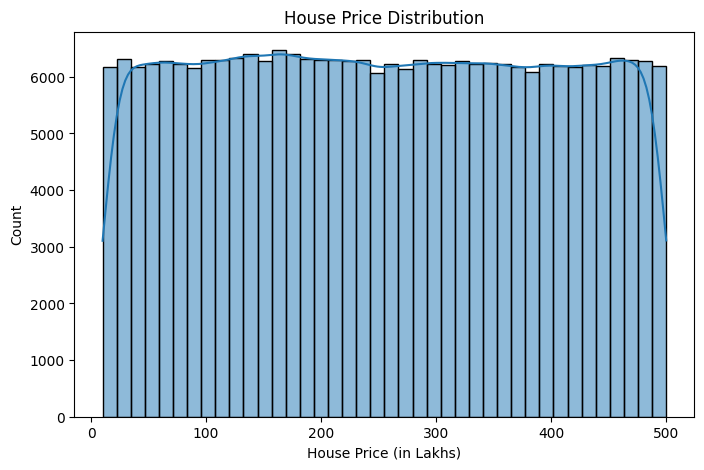

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price_in_Lakhs"], bins=40, kde=True)
plt.title("House Price Distribution")
plt.xlabel("House Price (in Lakhs)")
plt.ylabel("Count")
plt.show()


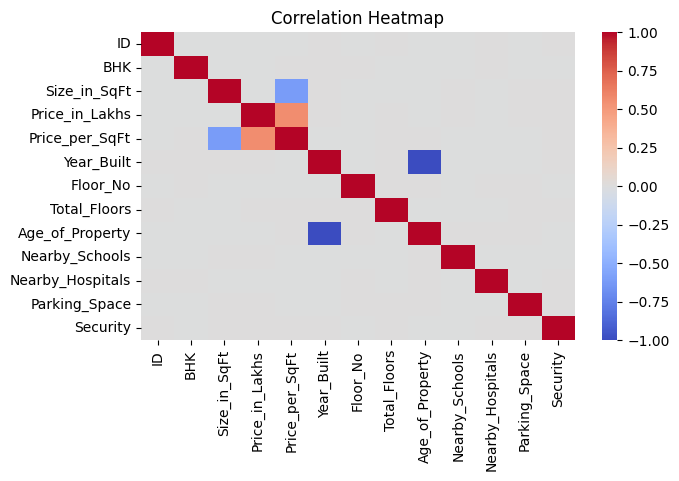

Price_in_Lakhs    1.000000
Price_per_SqFt    0.555625
Security          0.003808
Year_Built        0.002714
Total_Floors      0.001283
Parking_Space     0.001118
Nearby_Schools    0.000155
BHK              -0.000980
ID               -0.001636
Floor_No         -0.001719
Name: Price_in_Lakhs, dtype: float64

In [21]:
plt.figure(figsize=(7,4))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Top correlated features with price
corr["Price_in_Lakhs"].sort_values(ascending=False).head(10)



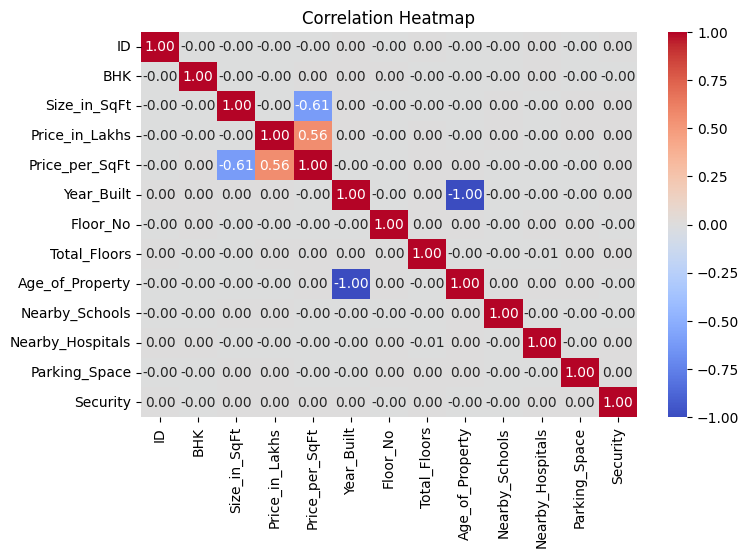

In [22]:
plt.figure(figsize=(8,5))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


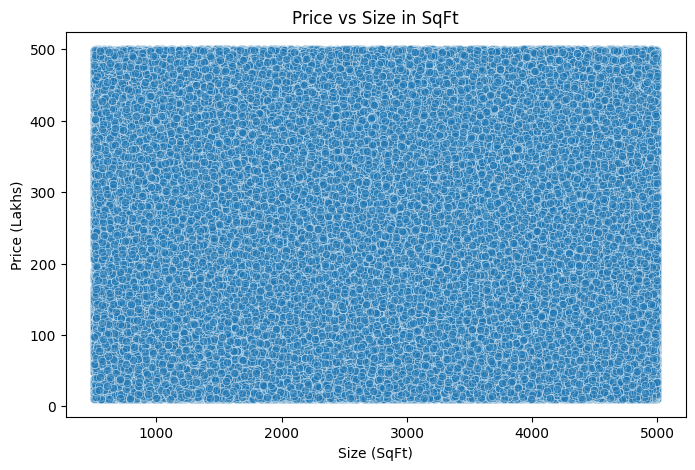

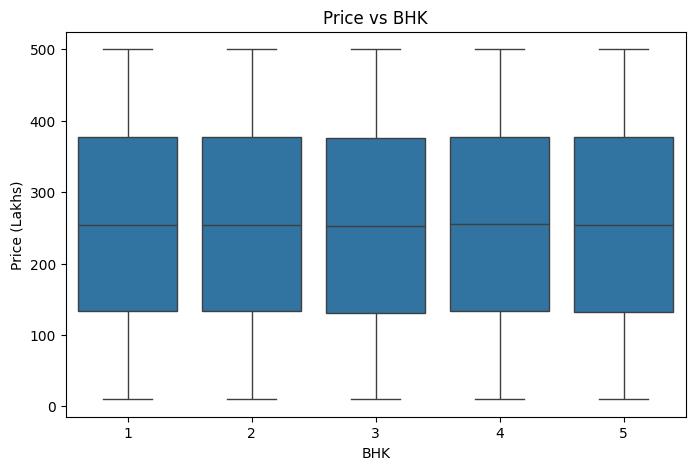

In [23]:
# Price vs Size in SqFt
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Size_in_SqFt"], y=df["Price_in_Lakhs"], alpha=0.5)
plt.title("Price vs Size in SqFt")
plt.xlabel("Size (SqFt)")
plt.ylabel("Price (Lakhs)")
plt.show()

# Price vs BHK (Bedrooms)
plt.figure(figsize=(8,5))
sns.boxplot(x=df["BHK"], y=df["Price_in_Lakhs"])
plt.title("Price vs BHK")
plt.xlabel("BHK")
plt.ylabel("Price (Lakhs)")
plt.show()


In [25]:
# Check unique values in Size_in_SqFt
print("Unique sizes:", df["Size_in_SqFt"].unique()[:20])  # first 20 unique values

# Check unique values in BHK
print("Unique BHK:", df["BHK"].unique())

# See if size is always proportional to BHK
df.groupby("BHK")["Size_in_SqFt"].mean()


Unique sizes: [4740 2364 3642 2741 4823 3500 4826 4252 2678 1393  665 3988 1976 1369
 3852 2815 1250 3518 2126 2524]
Unique BHK: [1 3 2 4 5]


BHK
1    2749.712029
2    2751.933996
3    2750.144926
4    2752.737628
5    2744.571748
Name: Size_in_SqFt, dtype: float64

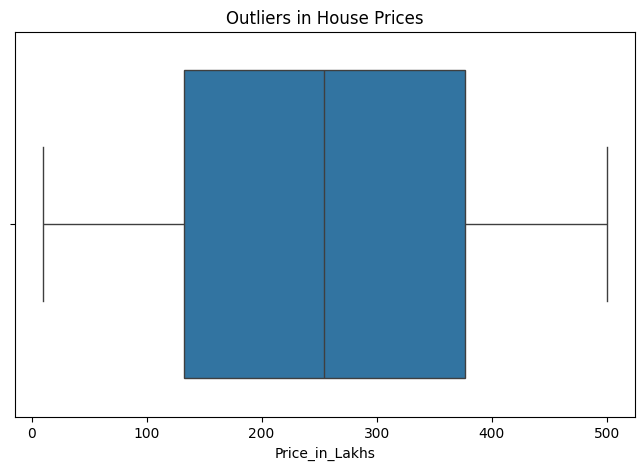

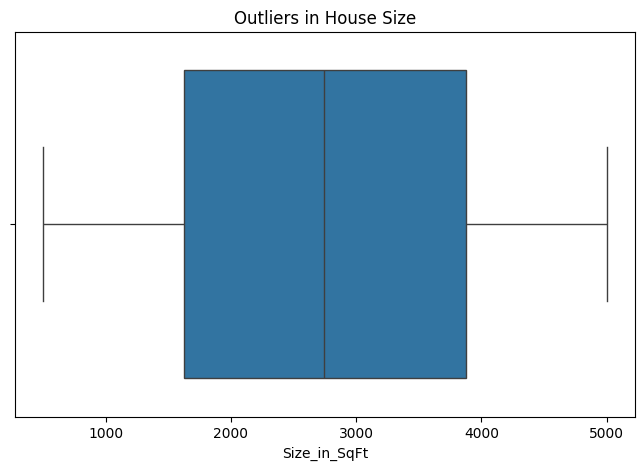

In [42]:
# Outliers in Price
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Price_in_Lakhs"])
plt.title("Outliers in House Prices")
plt.show()

# Outliers in Size
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Size_in_SqFt"])
plt.title("Outliers in House Size")
plt.show()


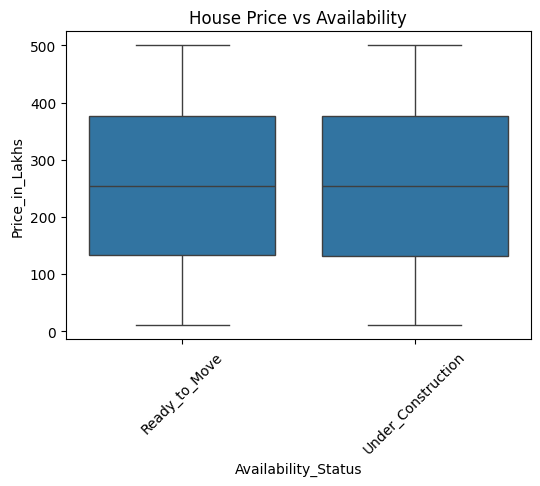

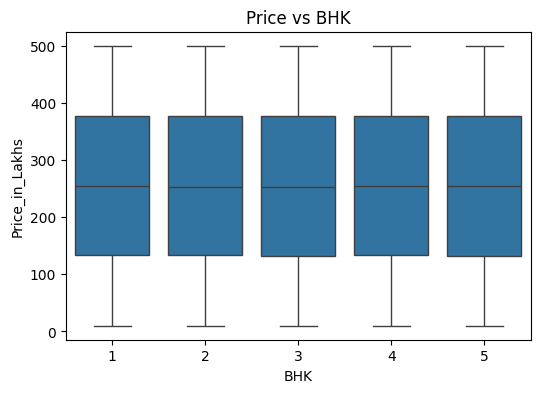

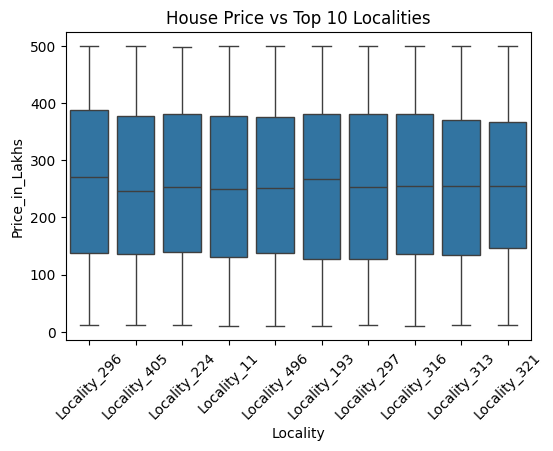

In [26]:
# Price vs Availability
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Availability_Status", y="Price_in_Lakhs")
plt.xticks(rotation=45)
plt.title("House Price vs Availability")
plt.show()

# Price vs BHK
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="BHK", y="Price_in_Lakhs")
plt.title("Price vs BHK")
plt.show()


# Price vs Locality (Top 10)
top_localities = df["Locality"].value_counts().head(10).index
plt.figure(figsize=(6,4))
sns.boxplot(data=df[df["Locality"].isin(top_localities)], x="Locality", y="Price_in_Lakhs")
plt.xticks(rotation=45)
plt.title("House Price vs Top 10 Localities")
plt.show()


In [34]:
import pandas as pd

# Load dataset
df = pd.read_csv("india_housing_prices.csv")

# Drop only 'Street' if it exists
if "Street" in df.columns:
    df = df.drop(columns=["Street"])

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values (for now, drop rows with nulls)
df = df.dropna()

print("Remaining columns after cleaning:", df.columns.tolist())
print("Final dataset shape:", df.shape)

df.head()


Remaining columns after cleaning: ['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']
Final dataset shape: (250000, 23)


,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,Furnished,22,1,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,Unfurnished,21,20,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,Semi-furnished,19,27,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,Furnished,21,26,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,Semi-furnished,3,2,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


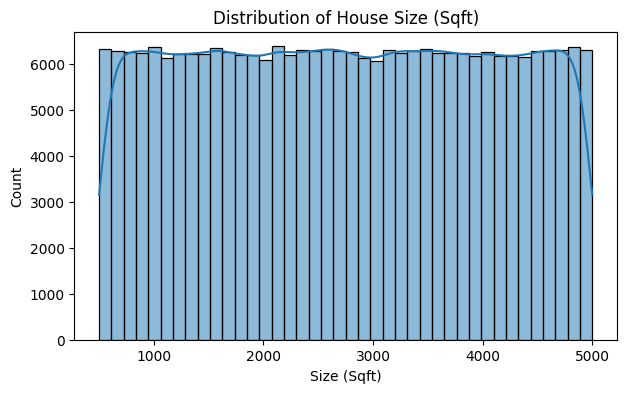

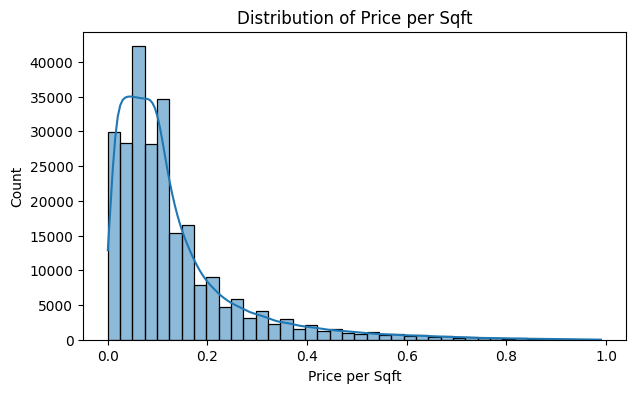

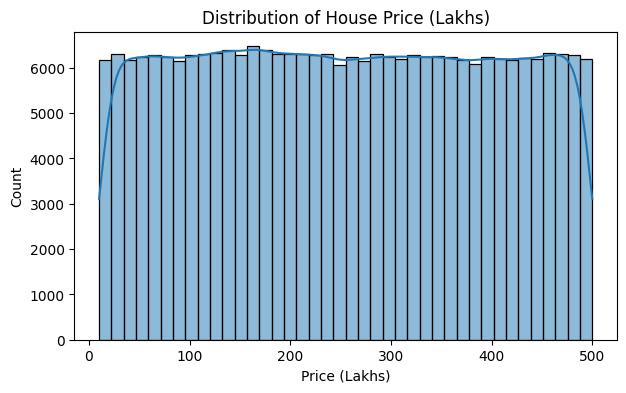

In [27]:
# Distribution of Size in Sqft
plt.figure(figsize=(7,4))
sns.histplot(df["Size_in_SqFt"], bins=40, kde=True)
plt.title("Distribution of House Size (Sqft)")
plt.xlabel("Size (Sqft)")
plt.show()

# Distribution of Price per Sqft
plt.figure(figsize=(7,4))
sns.histplot(df["Price_per_SqFt"], bins=40, kde=True)
plt.title("Distribution of Price per Sqft")
plt.xlabel("Price per Sqft")
plt.show()

# Distribution of Price
plt.figure(figsize=(7,4))
sns.histplot(df["Price_in_Lakhs"], bins=40, kde=True)
plt.title("Distribution of House Price (Lakhs)")
plt.xlabel("Price (Lakhs)")
plt.show()


In [35]:
import pandas as pd

# Load dataset
df = pd.read_csv("india_housing_prices.csv")

# Drop unnecessary column(s)
df = df.drop(columns=["Street"], errors="ignore")

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values (drop or fill)
df = df.dropna()

# Convert Yes/No type columns into 0/1
yes_no_cols = []
for col in df.columns:
    if df[col].dtype == "object":
        unique_vals = df[col].dropna().unique()
        if set(unique_vals) == {"Yes", "No"} or set(unique_vals) == {"No", "Yes"}:
            yes_no_cols.append(col)

# Apply conversion
for col in yes_no_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

print("Converted Yes/No columns:", yes_no_cols)
print("Final dataset shape:", df.shape)
df.head()


Converted Yes/No columns: ['Parking_Space', 'Security']
Final dataset shape: (250000, 23)


,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,Furnished,22,1,35,10,3,High,0,0,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,Unfurnished,21,20,17,8,1,Low,0,1,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,Semi-furnished,19,27,28,9,8,Low,1,0,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,Furnished,21,26,34,5,7,High,1,1,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,Semi-furnished,3,2,23,4,9,Low,0,1,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [52]:
print("Average Price of houses (Lakhs):", df["Price_in_Lakhs"].mean())
print("Average Size of houses (Sqft):", df["Size_in_SqFt"].mean())
print("Most common BHK:", df["BHK"].mode()[0])
print("Most common Availability:", df["Availability_Status"].mode()[0])


Average Price of houses (Lakhs): 254.58685403999996
Average Size of houses (Sqft): 2749.813216
Most common BHK: 1
Most common Availability: Under_Construction


In [29]:
df.to_csv("cleaned_data.csv", index=False)
print("Saved cleaned_data.csv | shape:", df.shape)


Saved cleaned_data.csv | shape: (250000, 23)
